# 02 · A/B Testing, Part 2: Analysing the Results and Making a Decision

In part 1 we designed the test and checked the data of the **Cookie Cats** experiment (first gate at level 30 vs level 40). Now we answer the question: **does moving the gate change retention?**

**What you will learn here**

1. Comparing two conversion rates with a two-proportion z-test, by hand and in Python
2. A confidence interval for the difference
3. The same answer with a bootstrap (no formulas)
4. Secondary metrics: 1-day retention and game rounds (Mann-Whitney U)
5. Multiple comparisons and the Bonferroni correction
6. Statistical vs practical significance
7. The decision, in plain words
8. Classic A/B testing mistakes, shown with simulations: peeking, too-small samples, novelty effects

**Dataset:** `data/cookie_cats.csv`, described in part 1.

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"     # gate_30 (control)
ORANGE = "#eb6834"   # gate_40 (treatment)
GREEN = "#1baf7a"

cookie = pd.read_csv("../data/cookie_cats.csv")

# same cleaning as in part 1: remove the one impossible player (49,854 rounds)
cookie = cookie[cookie["sum_gamerounds"] < 49_854]

control = cookie[cookie["version"] == "gate_30"]
treatment = cookie[cookie["version"] == "gate_40"]
print("control  (gate_30):", len(control), "players")
print("treatment (gate_40):", len(treatment), "players")

control  (gate_30): 44699 players
treatment (gate_40): 45489 players


---
## 1. The primary metric: 7-day retention

In [2]:
n_a, n_b = len(control), len(treatment)
x_a, x_b = control["retention_7"].sum(), treatment["retention_7"].sum()
p_a, p_b = x_a / n_a, x_b / n_b

print(f"gate_30: {x_a:,} of {n_a:,} came back on day 7 -> {p_a:.4f} ({p_a:.2%})")
print(f"gate_40: {x_b:,} of {n_b:,} came back on day 7 -> {p_b:.4f} ({p_b:.2%})")
print(f"difference (gate_40 - gate_30): {p_b - p_a:+.4f} ({(p_b - p_a) * 100:+.2f} percentage points)")
print(f"relative change: {(p_b - p_a) / p_a:+.1%}")

gate_30: 8,501 of 44,699 came back on day 7 -> 0.1902 (19.02%)
gate_40: 8,279 of 45,489 came back on day 7 -> 0.1820 (18.20%)
difference (gate_40 - gate_30): -0.0082 (-0.82 percentage points)
relative change: -4.3%


Moving the gate to level 40 **lowered** 7-day retention from 19.0% to 18.2%: 0.82 percentage points, or 4.3% in relative terms. Now: is that bigger than random noise?

---
## 2. Two-proportion z-test

> **Theory.** Each player is a Bernoulli trial (came back or not). We compare the two rates. If H₀ is true (no difference), both groups share one common rate, so we estimate it from all players together: the **pooled proportion**.

**Formulas**

$$\hat{p}_{pool} = \frac{x_A + x_B}{n_A + n_B}$$

$$SE = \sqrt{\hat{p}_{pool}(1 - \hat{p}_{pool})\left(\frac{1}{n_A} + \frac{1}{n_B}\right)}$$

$$z = \frac{\hat{p}_B - \hat{p}_A}{SE}$$

| Symbol | Meaning |
|---|---|
| $x_A$, $x_B$ | number of retained players in each group |
| $n_A$, $n_B$ | number of players in each group |
| $\hat{p}_A$, $\hat{p}_B$ | retention rate in each group |

**By hand** (rounded)

1. $\hat{p}_{pool} = (8{,}501 + 8{,}279) / (44{,}699 + 45{,}489) = 16{,}780 / 90{,}188 = 0.1861$
2. $SE = \sqrt{0.1861 \times 0.8139 \times (1/44{,}699 + 1/45{,}489)} = \sqrt{0.15146 \times 0.00004436} = \sqrt{0.000006719} = 0.002592$
3. $z = (0.1820 - 0.1902) / 0.002592 = -0.0082 / 0.002592 = \mathbf{-3.16}$
4. p-value = 2 × P(Z < −3.16) = 2 × 0.00079 = **0.0016**
5. 0.0016 < 0.05 → $\color{red}{\textbf{reject } H_0}$

In [3]:
p_pool = (x_a + x_b) / (n_a + n_b)
se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
z = (p_b - p_a) / se_pooled
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
p_value = 2 * stats.norm.cdf(-abs(z))

print(f"pooled proportion = {p_pool:.4f}")
print(f"standard error    = {se_pooled:.6f}")
print(f"z = {z:.3f}, p-value = {p_value:.4f}")

pooled proportion = 0.1861
standard error    = 0.002592
z = -3.157, p-value = 0.0016


In [4]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html
z_sm, p_sm = proportions_ztest(count=[x_b, x_a], nobs=[n_b, n_a])
print(f"statsmodels: z = {z_sm:.3f}, p-value = {p_sm:.4f}")

statsmodels: z = -3.157, p-value = 0.0016


> **Check:** Same result. The difference in 7-day retention is $\color{red}{\textbf{statistically significant}}$ (p ≈ 0.002).

---
## 3. Confidence interval for the difference

The p-value says "there is a difference". The confidence interval says **how big** it plausibly is. That's usually more useful for a business decision.

For the interval we don't assume H₀, so we use the **unpooled** standard error (each group with its own rate):

$$SE_{diff} = \sqrt{\frac{\hat{p}_A(1-\hat{p}_A)}{n_A} + \frac{\hat{p}_B(1-\hat{p}_B)}{n_B}}$$

$$CI_{95\%} = (\hat{p}_B - \hat{p}_A) \pm 1.96 \times SE_{diff}$$

In [5]:
se_diff = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
diff = p_b - p_a
low, high = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f"difference = {diff * 100:+.2f} points")
print(f"95% CI by hand     : [{low * 100:+.2f}, {high * 100:+.2f}] points")

# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.confint_proportions_2indep.html
low_sm, high_sm = confint_proportions_2indep(x_b, n_b, x_a, n_a, method="wald")
print(f"95% CI statsmodels : [{low_sm * 100:+.2f}, {high_sm * 100:+.2f}] points")

difference = -0.82 points
95% CI by hand     : [-1.33, -0.31] points
95% CI statsmodels : [-1.33, -0.31] points


**Reading it:** with 95% confidence, moving the gate to level 40 changes 7-day retention by somewhere between **−1.3 and −0.3 percentage points**. The whole interval is below zero, so a positive effect is very unlikely. This agrees with the z-test.

---
## 4. Checking with a bootstrap

> **Theory.** The **bootstrap** estimates uncertainty by simulation instead of formulas:

1. Draw a new sample **with replacement** from each group, of the same size as the original.
2. Compute the retention difference.
3. Repeat thousands of times.
4. The spread of those differences shows how much the result could wobble.

**Why do we need it?** It works for almost any metric (medians, ratios, revenue per user) where no simple formula exists. It's a good habit to confirm a formula result with it.

> **Note:** Speed trick: resampling n zeros/ones with replacement and counting the ones is exactly the same as drawing from a binomial distribution with that n and rate. So instead of resampling 90,000 rows 5,000 times, we draw binomial numbers. Same maths, much faster.

Read more: [Bootstrapping (Wikipedia)](https://en.wikipedia.org/wiki/Bootstrapping_(statistics))

In [6]:
np.random.seed(42)
n_boot = 5000

boot_a = np.random.binomial(n_a, p_a, size=n_boot) / n_a
boot_b = np.random.binomial(n_b, p_b, size=n_boot) / n_b
boot_diff = boot_b - boot_a

# docs: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html
boot_low, boot_high = np.percentile(boot_diff, [2.5, 97.5])
print(f"bootstrap 95% CI: [{boot_low * 100:+.2f}, {boot_high * 100:+.2f}] points")
print(f"share of bootstrap samples where gate_30 has higher retention: {(boot_diff < 0).mean():.1%}")

bootstrap 95% CI: [-1.32, -0.30] points
share of bootstrap samples where gate_30 has higher retention: 99.8%


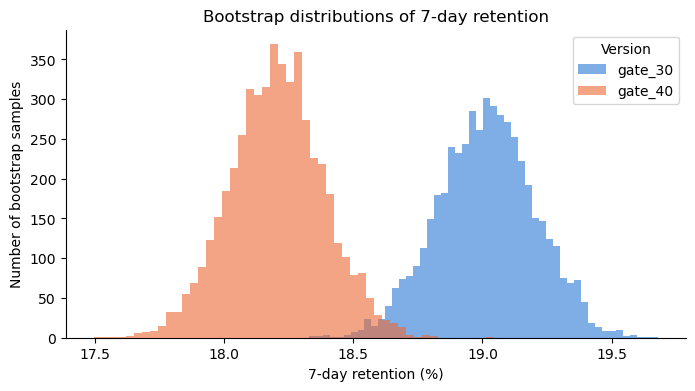

In [7]:
fig, ax = plt.subplots()
ax.hist(boot_a * 100, bins=50, color=BLUE, alpha=0.6, label="gate_30")
ax.hist(boot_b * 100, bins=50, color=ORANGE, alpha=0.6, label="gate_40")
ax.set_title("Bootstrap distributions of 7-day retention")
ax.set_xlabel("7-day retention (%)")
ax.set_ylabel("Number of bootstrap samples")
ax.legend(title="Version")
plt.show()

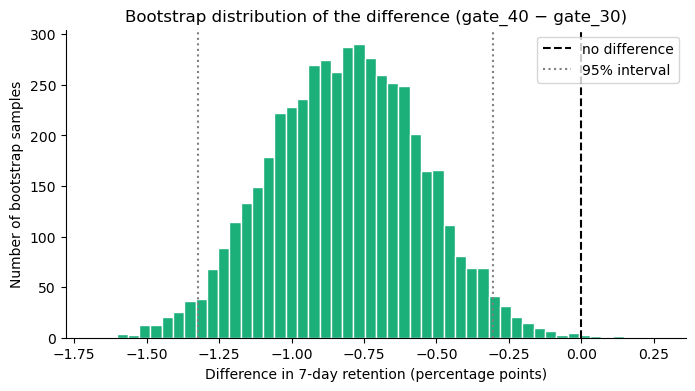

In [8]:
fig, ax = plt.subplots()
ax.hist(boot_diff * 100, bins=50, color=GREEN, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", label="no difference")
ax.axvline(boot_low * 100, color="grey", linestyle=":", label="95% interval")
ax.axvline(boot_high * 100, color="grey", linestyle=":")
ax.set_title("Bootstrap distribution of the difference (gate_40 − gate_30)")
ax.set_xlabel("Difference in 7-day retention (percentage points)")
ax.set_ylabel("Number of bootstrap samples")
ax.legend()
plt.show()

The two retention distributions barely overlap, and the difference distribution sits entirely to the left of zero. In almost every bootstrap sample (about 99.8%), gate_30 keeps more players. Same conclusion as the formula, without any formula.

---
## 5. Secondary metrics

### 5a. 1-day retention

In [9]:
x1_a, x1_b = control["retention_1"].sum(), treatment["retention_1"].sum()
r1_a, r1_b = x1_a / n_a, x1_b / n_b

z1, p1 = proportions_ztest(count=[x1_b, x1_a], nobs=[n_b, n_a])
low1, high1 = confint_proportions_2indep(x1_b, n_b, x1_a, n_a, method="wald")

print(f"gate_30: {r1_a:.2%}   gate_40: {r1_b:.2%}   difference: {(r1_b - r1_a) * 100:+.2f} points")
print(f"z = {z1:.2f}, p = {p1:.3f}, 95% CI = [{low1 * 100:+.2f}, {high1 * 100:+.2f}] points")

gate_30: 44.82%   gate_40: 44.23%   difference: -0.59 points
z = -1.79, p = 0.074, 95% CI = [-1.24, +0.06] points


Also lower for gate_40 (−0.59 points), but $\color{green}{\textbf{not significant}}$ (p = 0.074), and the interval includes 0. This makes sense: one day after installing, most players haven't reached level 30 yet, so the gate position can't matter much for them.

### 5b. Game rounds: why not a t-test?

Game rounds are extremely skewed (part 1). The t-test compares **means**, and with this kind of data the mean is driven by a few heavy players. The **Mann-Whitney U test** is a non-parametric alternative: it uses ranks and asks "if I pick one random player from each group, is one group more likely to have played more rounds?" It is not affected by extreme values.

(We cover Mann-Whitney with a worked example in notebook 03 of this folder.)

In [10]:
rounds_a = control["sum_gamerounds"]
rounds_b = treatment["sum_gamerounds"]

print(f"mean   rounds: gate_30 = {rounds_a.mean():.2f}, gate_40 = {rounds_b.mean():.2f}")
print(f"median rounds: gate_30 = {rounds_a.median():.0f}, gate_40 = {rounds_b.median():.0f}")
print()

# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html
mw = stats.mannwhitneyu(rounds_b, rounds_a, alternative="two-sided")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
welch = stats.ttest_ind(rounds_b, rounds_a, equal_var=False)
print(f"Mann-Whitney U: p = {mw.pvalue:.3f}")
print(f"Welch t-test  : p = {welch.pvalue:.3f}")

mean   rounds: gate_30 = 51.34, gate_40 = 51.30
median rounds: gate_30 = 17, gate_40 = 16

Mann-Whitney U: p = 0.051
Welch t-test  : p = 0.949


No clear difference in how much people play: the means are almost identical, the medians differ by 1 round, and neither test reaches significance (Mann-Whitney is borderline at about 0.05). Moving the gate did not noticeably change the amount of play in the first 14 days.

---
## 6. Multiple comparisons

> **Theory.** We tested **3** metrics. Each test at α = 0.05 has a 5% false alarm chance, so the chance that **at least one** of three is a false alarm is about 1 − 0.95³ ≈ 14%.

The simplest fix is the **Bonferroni correction**: divide α by the number of tests.

$$\alpha_{corrected} = \frac{0.05}{3} = 0.0167$$

It's conservative (strict), but easy and safe.

Read more: [Bonferroni correction (Wikipedia)](https://en.wikipedia.org/wiki/Bonferroni_correction)

In [11]:
results = pd.DataFrame({
    "metric": ["retention_7 (primary)", "retention_1", "sum_gamerounds"],
    "p_value": [p_sm, p1, mw.pvalue],
})
alpha_bonferroni = 0.05 / len(results)
results["significant at 0.05"] = results["p_value"] < 0.05
results["significant after Bonferroni (0.0167)"] = results["p_value"] < alpha_bonferroni
results.round(4)

,metric,p_value,significant at 0.05,significant after Bonferroni (0.0167)
0,retention_7 (primary),0.0016,True,True
1,retention_1,0.0739,False,False
2,sum_gamerounds,0.0509,False,False


The primary metric stays significant even with the stricter threshold. Good: and remember that we picked retention_7 as the primary metric **before** looking at the results, which is the strongest protection against this problem.

---
## 7. Statistical vs practical significance

"Significant" means "probably not noise". It doesn't automatically mean "important". So let's translate the effect into something concrete.

In [12]:
new_players_per_month = 1_000_000   # an illustrative number, not from the data

lost_low = -high * new_players_per_month
lost_mid = -diff * new_players_per_month
lost_high = -low * new_players_per_month
print(f"Per {new_players_per_month:,} new players, the gate at level 40 means about "
      f"{lost_mid:,.0f} fewer players still active on day 7")
print(f"(plausible range: {lost_low:,.0f} to {lost_high:,.0f})")

Per 1,000,000 new players, the gate at level 40 means about 8,183 fewer players still active on day 7
(plausible range: 3,103 to 13,263)


For a game with a million new installs a month (an illustrative number), that's around **8,000 fewer players still playing after a week**, every month. Retained players are the ones who may pay later, so this is a meaningful loss. The effect is small in percentage points but not small in business terms.

---
## 8. Decision

**Recommendation: keep the first gate at level 30.**

**For a non-technical audience (two sentences):**

> Moving the first gate from level 30 to level 40 made slightly fewer players come back after a week (18.2% vs 19.0%), and this difference is very unlikely to be chance. The later gate did not make people play more either, so there is no upside to compensate and we should keep the gate at level 30.

**Why could an earlier gate keep more players?** A possible explanation is that the forced break makes players come back later with fresh interest, instead of playing until they get bored (a "hedonic adaptation" effect). The data cannot prove *why*, only *that*.

**Limitations to report honestly:**

| Limitation | Effect on the conclusion |
|---|---|
| Sample ratio mismatch (49.6% / 50.4%, p ≈ 0.009, part 1) | Should be investigated with the engineers before final sign-off |
| Effect is diluted: about 63% of players never reached level 30 | The effect among players who actually hit the gate is likely larger than 0.8 points |
| Only 14 days of data | We don't know the effect on long-term retention or revenue |
| One game, one time period | Results may not transfer to other games or seasons |

---
## 9. Classic A/B testing mistakes (with simulations)

### Mistake 1: peeking

**Peeking** means checking the p-value every day and stopping as soon as it drops below 0.05. It feels efficient, but it breaks the test: with many looks, random noise will cross 0.05 at some point.

Let's prove it with **A/A tests**: both groups get the **same** version (true retention 19% for both), so every "significant" result is a false alarm. Each simulated test runs 20 days with 1,000 new users per group per day.

In [13]:
np.random.seed(7)
n_experiments = 2000
days = 20
users_per_day = 1000
true_rate = 0.19

false_alarm_end_only = 0
false_alarm_peeking = 0

for _ in range(n_experiments):
    daily_a = np.random.binomial(users_per_day, true_rate, size=days)
    daily_b = np.random.binomial(users_per_day, true_rate, size=days)
    cum_a, cum_b = np.cumsum(daily_a), np.cumsum(daily_b)
    n_cum = users_per_day * np.arange(1, days + 1)

    rate_a, rate_b = cum_a / n_cum, cum_b / n_cum
    pooled = (cum_a + cum_b) / (2 * n_cum)
    se = np.sqrt(pooled * (1 - pooled) * (2 / n_cum))
    daily_p_values = 2 * stats.norm.cdf(-np.abs((rate_b - rate_a) / se))

    if daily_p_values[-1] < 0.05:
        false_alarm_end_only += 1
    if (daily_p_values < 0.05).any():
        false_alarm_peeking += 1

print(f"Check once at the end     : false alarm rate = {false_alarm_end_only / n_experiments:.1%}")
print(f"Check every day, stop at p<0.05: false alarm rate = {false_alarm_peeking / n_experiments:.1%}")

Check once at the end     : false alarm rate = 4.8%
Check every day, stop at p<0.05: false alarm rate = 25.2%


Checking once at the planned end gives the promised ~5% false alarm rate. Peeking every day and stopping at the first p < 0.05 gives about **25%**, five times higher, even though there is no real difference at all.

**How to avoid it:** decide the sample size in advance (part 1) and only make the decision at the end. If you really need to look early, use methods designed for it (sequential testing, or a much stricter early threshold).

Read more: Evan Miller, [How Not To Run an A/B Test](https://www.evanmiller.org/how-not-to-run-an-ab-test.html), the classic short article on peeking

Let's look at one of these A/A experiments day by day:

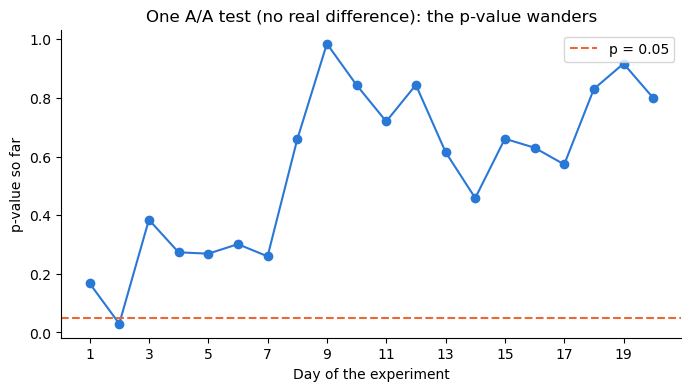

In [14]:
np.random.seed(11)
for attempt in range(200):
    daily_a = np.random.binomial(users_per_day, true_rate, size=days)
    daily_b = np.random.binomial(users_per_day, true_rate, size=days)
    cum_a, cum_b = np.cumsum(daily_a), np.cumsum(daily_b)
    n_cum = users_per_day * np.arange(1, days + 1)
    pooled = (cum_a + cum_b) / (2 * n_cum)
    se = np.sqrt(pooled * (1 - pooled) * (2 / n_cum))
    p_path = 2 * stats.norm.cdf(-np.abs((cum_b / n_cum - cum_a / n_cum) / se))
    if (p_path < 0.05).any() and p_path[-1] > 0.3:
        break

fig, ax = plt.subplots()
ax.plot(np.arange(1, days + 1), p_path, marker="o", color=BLUE)
ax.axhline(0.05, color=ORANGE, linestyle="--", label="p = 0.05")
ax.set_xticks(range(1, days + 1, 2))
ax.set_title("One A/A test (no real difference): the p-value wanders")
ax.set_xlabel("Day of the experiment")
ax.set_ylabel("p-value so far")
ax.legend()
plt.show()

The p-value dips below 0.05 at some point, then goes back up. Someone peeking on that day would have declared a "winner" for a change that does nothing.

### Mistake 2: too small a sample (and the winner's curse)

With a small sample, a test has low power, so it usually misses real effects. Worse: when it *does* find one, the effect it reports is usually **exaggerated**, because only the lucky, extreme results cross the significance line.

Simulation: the true effect is −0.8 points (like our real result), but each experiment only has 3,000 users per group.

In [15]:
np.random.seed(3)
true_a, true_b = 0.190, 0.182
small_n = 3000

significant_effects = []
for _ in range(5000):
    a = np.random.binomial(small_n, true_a) / small_n
    b = np.random.binomial(small_n, true_b) / small_n
    pooled = (a + b) / 2
    se = np.sqrt(pooled * (1 - pooled) * (2 / small_n))
    if 2 * stats.norm.cdf(-abs((b - a) / se)) < 0.05:
        significant_effects.append(b - a)

power = len(significant_effects) / 5000
print(f"Power with {small_n:,} users per group: {power:.1%}")
print(f"True effect: {(true_b - true_a) * 100:+.1f} points")
print(f"Average effect among the 'significant' results: {np.mean(np.abs(significant_effects)) * 100:.1f} points (in absolute value)")

Power with 3,000 users per group: 13.1%
True effect: -0.8 points
Average effect among the 'significant' results: 2.5 points (in absolute value)


With 3,000 users per group the test almost never detects the real effect. And in the rare cases it does, the reported effect is several times larger than the truth. Underpowered tests that "win" are often a mirage, which is why the power analysis in part 1 matters.

### Mistake 3: novelty and primacy effects

Not a simulation, but just as important:

- **Novelty effect:** users click on something new just because it's new. The effect fades after a few days.
- **Primacy effect:** users dislike change at first, even if the new version is better. The effect improves over time.

Both mean that the first days of a test can mislead. Run tests over at least one or two full weeks (to cover weekday and weekend behaviour) and compare early vs late results. In our case only new players were in the test, so they had no old version to compare with: that's a nice way to avoid novelty and primacy effects.

### Quick checklist

| Before | During | After |
|---|---|---|
| One primary metric, chosen in advance | Don't peek and stop early | Check sample ratio (SRM) |
| Hypotheses and α written down | Don't change the setup mid-test | Report effect size + CI, not just p |
| Sample size from a power analysis | Run full weeks | Correct for multiple comparisons |
| Random assignment per user | | Translate into business impact |

---
## Summary

| Question | Answer |
|---|---|
| Effect on 7-day retention | −0.82 points (19.0% → 18.2%), p ≈ 0.002, 95% CI [−1.3, −0.3] |
| Confirmed by bootstrap? | Yes, gate_30 better in about 99.8% of resamples |
| Effect on 1-day retention | −0.59 points, not significant |
| Effect on game rounds | No clear difference |
| After Bonferroni | Primary result still significant |
| Decision | Keep the gate at level 30 |

## What's next

In **03 · Other Statistical Tests** we go through the other tests a data scientist uses all the time (two-sample and paired t-tests, chi-square test of independence, ANOVA, correlation tests, Mann-Whitney U), each with a short real example, and finish with a "which test should I use?" table.

## References and further reading

- Kohavi, Tang & Xu (2020), *Trustworthy Online Controlled Experiments*, chapters on analysis, pitfalls and trustworthiness checks
- Evan Miller, [How Not To Run an A/B Test](https://www.evanmiller.org/how-not-to-run-an-ab-test.html) (peeking)
- [Bootstrapping (statistics), Wikipedia](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)) · [Multiple comparisons problem, Wikipedia](https://en.wikipedia.org/wiki/Multiple_comparisons_problem)
- [statsmodels `proportions_ztest`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html) · [statsmodels `confint_proportions_2indep`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.confint_proportions_2indep.html)